# Diagnostic de Défauts — Moteur CC 12V
# Classification Binaire : Normal vs Surcharge
# Capteurs : Tension (V) + Courant (A) uniquement

---

**Dataset** : 6 fichiers CSV — mesures réelles ESP32

**Capteurs** : Tension (V) + Courant (A) — 2 capteurs seulement

**Features** : 15 × 2 = **30 features** par fenêtre

**Cible** : ESP32 — code C compact via m2cgen

---

## Table des matières

1. Contexte
2. Installation
3. Chargement et nettoyage
4. Analyse exploratoire
5. Segmentation en fenêtres
6. Extraction des 30 features
7. Préparation des données
8. Entraînement et évaluation
9. Résultats
10. Export ESP32

---
## 1. Contexte

### Pourquoi seulement Tension + Courant ?

- **Disponibilité** : 4 fichiers sur 6 n'ont pas de capteur de vitesse → imputation forcée à 0 qui biaise les features Vitesse
- **Physique** : la surcharge se manifeste principalement par une **hausse du courant** et une **chute de tension** — ces 2 capteurs sont les plus discriminants
- **Déploiement** : 2 capteurs = câblage plus simple sur ESP32, et 30 features au lieu de 45

### Inventaire des 6 fichiers

| Fichier | Label | Courant disponible |
|---------|-------|:------------------:|
| `dataset_moteur.csv` | Normal | ✗ → imputé 0 |
| `dataset_finale_eet_5A.csv` | Normal | ✓ ~1.24 A |
| `dataset_trés_finale_30A.csv` | Normal | ✓ ~0.05 A |
| `dataset_surcharge.csv` | Surcharge | ✗ → imputé 0 |
| `dataset_surcharge_5A.csv` | Surcharge | ✓ ~1.22 A |
| `dataset_surcharge_30AA.csv` | Surcharge | ✓ ~0.16 A |

### Corrections appliquées

| Problème | Correction |
|----------|------------|
| En-tête PuTTY (boot ESP32) | Skip jusqu'à ligne `Temps` |
| Décimal virgule `,` | `decimal=','` |
| `Tension(V),` virgule parasite | `rstrip(',')` |
| Tension = 0 V (moteur éteint) | Suppression |
| Courant > 5 A (pic aberrant) | Suppression |
| NaN de fin de fichier | `dropna()` |
| Colonne Courant absente | Imputation à 0 |

---
## 2. Installation des dépendances

In [1]:
# Décommenter si exécution dans Google Colab :
%pip install m2cgen scikit-learn pandas numpy matplotlib seaborn scipy -q

Note: you may need to restart the kernel to use updated packages.


---
## 3. Chargement et nettoyage des données

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from pathlib import Path
warnings.filterwarnings("ignore")

# ================================================================
# CONFIGURATION — adapter le chemin si nécessaire
# ================================================================
DATA_DIR = Path.cwd()
if not (DATA_DIR / "dataset_moteur (1).csv").exists():
    DATA_DIR = DATA_DIR / "dataset jloud"

def find_csv(*patterns):
    for pattern in patterns:
        matches = sorted(DATA_DIR.glob(pattern))
        if matches:
            return matches[0].name
    raise FileNotFoundError(f"Aucun CSV trouvé dans {DATA_DIR} pour: {patterns}")

FILES_CONFIG = {
    # clé : (nom_fichier, label, décimal, skip_putty)
    "moteur":        (find_csv("dataset_moteur*.csv"),              "Normal",    ",", False),
    "finale_5A":     (find_csv("dataset finale eet 5A*.csv"),       "Normal",    ".", False),
    "finale_30A":    (find_csv("dataset*finale 30A.csv"),           "Normal",    ".", False),
    "surcharge":     (find_csv("dataset surcharge*.csv", "dataset_surcharge*.csv"), "Surcharge", ",", False),
    "surcharge_5A":  (find_csv("dataset surcharge 5A*.csv"),        "Surcharge", ".", True),
    "surcharge_30A": (find_csv("dataset surcharge 30AA*.csv"),      "Surcharge", ".", True),
}

SENSORS      = ["Tension(V)", "Courant(A)"]
LABEL_TO_INT = {"Normal": 0, "Surcharge": 1}
CLASS_NAMES  = list(LABEL_TO_INT.keys())
COLORS       = {"Normal": "#2196F3", "Surcharge": "#FF5722"}

In [3]:
def load_and_clean(file_path, label, decimal=".", skip_putty=False):
    with open(file_path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    if skip_putty:
        start = next(i for i, line in enumerate(lines) if "Temps" in line)
        lines = lines[start:]

    df = pd.read_csv(StringIO("".join(lines)), sep=";", decimal=decimal)
    df.columns = [col.strip().rstrip(",") for col in df.columns]

    numeric_cols = ["Temps(ms)", "Tension(V)", "Courant(A)"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col].astype(str).str.strip().str.replace(",", ".", regex=False),
                errors="coerce"
            )

    df = df.dropna(subset=["Temps(ms)", "Tension(V)"])
    df = df[df["Tension(V)"] >= 1.0]
    if "Courant(A)" in df.columns:
        df = df[df["Courant(A)"] <= 5.0]
    else:
        df["Courant(A)"] = 0.0

    df = df[["Temps(ms)"] + SENSORS].copy()
    df["Label"] = label
    df["Source"] = Path(file_path).stem
    return df.reset_index(drop=True)


print("=" * 65)
print("CHARGEMENT ET NETTOYAGE DES DONNEES")
print("=" * 65)

all_dfs = {}
for name, (filename, label, decimal, skip_putty) in FILES_CONFIG.items():
    path = Path(DATA_DIR) / filename
    df = load_and_clean(path, label, decimal, skip_putty)
    all_dfs[name] = df
    courant_status = "present" if df["Courant(A)"].std() > 0 else "impute=0"
    print(f"  {name:<18} [{label:<10}] {len(df):>5} pts | Courant {courant_status}")

total = sum(len(df) for df in all_dfs.values())
print(f"\n  Total lignes nettoyees : {total}")
print(f"  Normal    : {sum(len(df) for df in all_dfs.values() if not df.empty and df['Label'].iloc[0] == 'Normal')}")
print(f"  Surcharge : {sum(len(df) for df in all_dfs.values() if not df.empty and df['Label'].iloc[0] == 'Surcharge')}")


CHARGEMENT ET NETTOYAGE DES DONNEES
  moteur             [Normal    ]  3574 pts | Courant impute=0
  finale_5A          [Normal    ]   843 pts | Courant present
  finale_30A         [Normal    ]   708 pts | Courant present
  surcharge          [Surcharge ]  3689 pts | Courant impute=0
  surcharge_5A       [Surcharge ]   740 pts | Courant present
  surcharge_30A      [Surcharge ]   572 pts | Courant present

  Total lignes nettoyees : 10126
  Normal    : 5125
  Surcharge : 5001


---
## 4. Analyse exploratoire des données

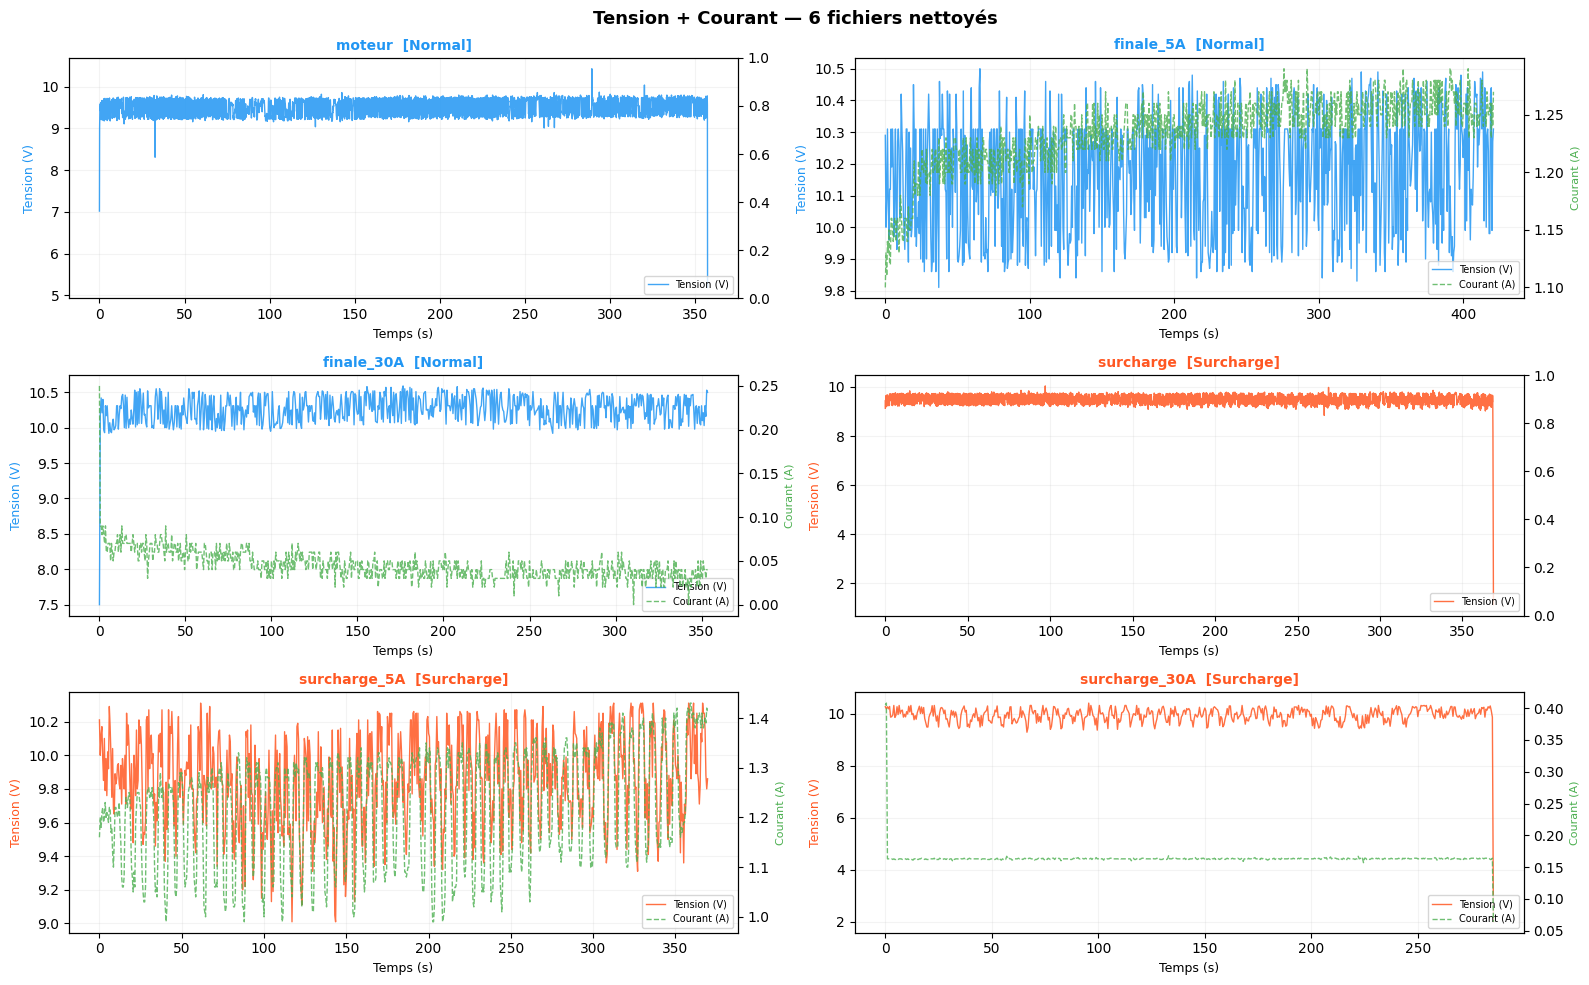

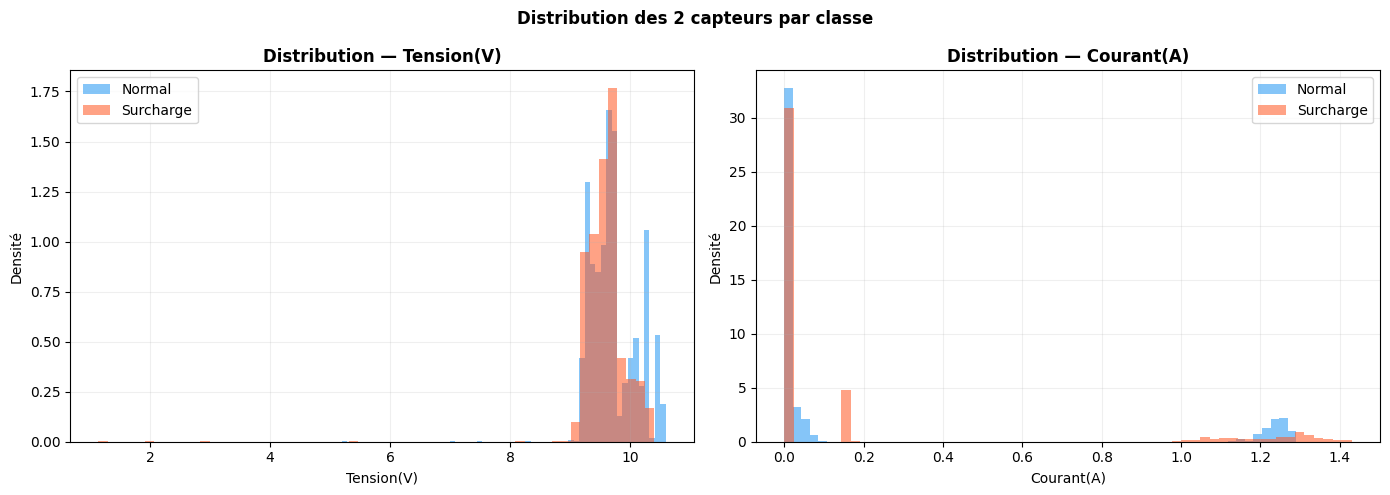

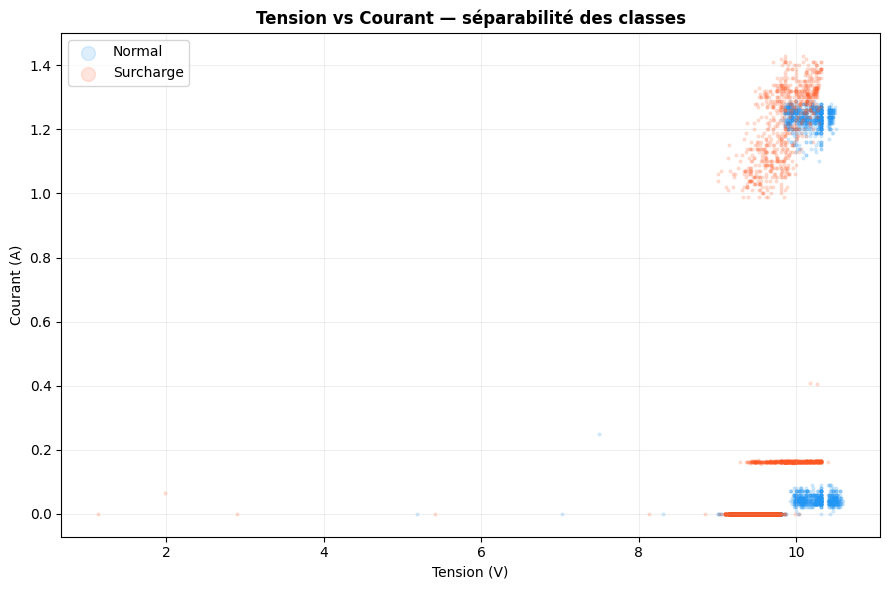

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes_flat = axes.flatten()

for idx, (name, df) in enumerate(all_dfs.items()):
    ax  = axes_flat[idx]
    ax2 = ax.twinx()
    lbl = df["Label"].iloc[0]
    col = COLORS[lbl]
    t   = df["Temps(ms)"].values / 1000

    ax.plot(t, df["Tension(V)"], color=col, lw=1, alpha=0.85, label="Tension (V)")
    if df["Courant(A)"].std() > 0:
        ax2.plot(t, df["Courant(A)"], color="#4CAF50", lw=1,
                 alpha=0.8, linestyle="--", label="Courant (A)")
        ax2.set_ylabel("Courant (A)", fontsize=8, color="#4CAF50")

    ax.set_title(f"{name}  [{lbl}]", fontsize=10, fontweight="bold", color=col)
    ax.set_xlabel("Temps (s)", fontsize=9)
    ax.set_ylabel("Tension (V)", color=col, fontsize=9)
    ax.grid(True, alpha=0.15)
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, loc="lower right", fontsize=7)

plt.suptitle("Tension + Courant — 6 fichiers nettoyés", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Distribution par capteur
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, sensor in enumerate(SENSORS):
    ax = axes[idx]
    has_data = False
    for label, color in COLORS.items():
        series_list = [
            df[sensor]
            for df in all_dfs.values()
            if not df.empty and df["Label"].iloc[0] == label
        ]
        if not series_list:
            continue

        data = pd.concat(series_list, ignore_index=True)
        if data.std() > 1e-6:
            ax.hist(data, bins=60, alpha=0.55, color=color, label=label, density=True)
            has_data = True
    ax.set_title(f"Distribution — {sensor}", fontweight="bold")
    ax.set_xlabel(sensor); ax.set_ylabel("Densité")
    if has_data:
        ax.legend()
    ax.grid(True, alpha=0.2)
plt.suptitle("Distribution des 2 capteurs par classe", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Scatter Tension vs Courant
fig, ax = plt.subplots(figsize=(9, 6))
has_scatter_data = False
for label, color in COLORS.items():
    frames = [df for df in all_dfs.values() if not df.empty and df["Label"].iloc[0] == label]
    if not frames:
        continue

    combined = pd.concat(frames, ignore_index=True)
    ax.scatter(combined["Tension(V)"], combined["Courant(A)"],
               c=color, alpha=0.15, s=4, label=label)
    has_scatter_data = True
ax.set_xlabel("Tension (V)"); ax.set_ylabel("Courant (A)")
ax.set_title("Tension vs Courant — séparabilité des classes", fontweight="bold")
if has_scatter_data:
    ax.legend(markerscale=5)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
## 5. Segmentation en fenêtres glissantes

- **Taille** : 30 échantillons
- **Stride** : 15 (50 % de recouvrement)
- Chaque fenêtre → 1 échantillon pour le classifieur

In [5]:
WINDOW_SIZE = 30
STRIDE      = 15


def segment(df, window_size=WINDOW_SIZE, stride=STRIDE):
    windows, labels = [], []
    vals = df[SENSORS].values
    lbl  = LABEL_TO_INT[df["Label"].iloc[0]]
    n    = len(vals)
    i    = 0
    while i + window_size <= n:
        windows.append(vals[i:i + window_size])
        labels.append(lbl)
        i += stride
    return windows, labels


print(f"Segmentation : fenetre={WINDOW_SIZE}  stride={STRIDE}  capteurs=2")
print("=" * 55)

all_windows, all_labels = [], []
for name, df in all_dfs.items():
    wins, labs = segment(df)
    all_windows.extend(wins)
    all_labels.extend(labs)
    print(f"  {name:<18} -> {len(wins):>4} fenetres  [{df['Label'].iloc[0]}]")

all_windows = np.array(all_windows)   # (N, 30, 2)
all_labels  = np.array(all_labels)

n_norm  = np.sum(all_labels == 0)
n_surch = np.sum(all_labels == 1)
print(f"\n  Total    : {len(all_windows)}")
print(f"  Normal   : {n_norm}")
print(f"  Surcharge: {n_surch}")
print(f"  Ratio    : 1:{n_surch/n_norm:.2f}")

Segmentation : fenetre=30  stride=15  capteurs=2
  moteur             ->  237 fenetres  [Normal]
  finale_5A          ->   55 fenetres  [Normal]
  finale_30A         ->   46 fenetres  [Normal]
  surcharge          ->  244 fenetres  [Surcharge]
  surcharge_5A       ->   48 fenetres  [Surcharge]
  surcharge_30A      ->   37 fenetres  [Surcharge]

  Total    : 667
  Normal   : 338
  Surcharge: 329
  Ratio    : 1:0.97


---
## 6. Extraction des 30 caractéristiques

**15 features × 2 capteurs = 30 features**

### Temporelles (10 par capteur)

| # | Feature | Formule |
|---|---------|--------|
| 1 | Moyenne | μ = (1/N) Σxᵢ |
| 2 | Écart-type | σ |
| 3 | RMS | √[(1/N) Σxᵢ²] |
| 4 | Maximum | max(x) |
| 5 | Minimum | min(x) |
| 6 | Peak-to-peak | max − min |
| 7 | Kurtosis | E[(x−μ)⁴]/σ⁴ − 3 |
| 8 | Skewness | E[(x−μ)³]/σ³ |
| 9 | MAD | (1/N) Σ|xᵢ−xᵢ₋₁| |
| 10 | IQR | Q75 − Q25 |

### Fréquentielles (5 par capteur)

| # | Feature | Description |
|---|---------|-------------|
| 11 | Énergie spectrale | Σ|FFT|² |
| 12 | Fréquence dominante | Fréquence du pic max |
| 13 | Fréquence moyenne pondérée | Barycentre fréquentiel |
| 14 | Dispersion spectrale | σ des amplitudes |
| 15 | Ratio pic spectral | Pic / Somme totale |

In [6]:
from scipy.stats import kurtosis, skew

SENSOR_NAMES   = ["Tension", "Courant"]
TEMPORAL_FEATS = ["Mean","Std","RMS","Max","Min","PeakToPeak",
                  "Kurtosis","Skewness","MAD","IQR"]
SPECTRAL_FEATS = ["SpectralEnergy","DominantFreq","MeanFreq",
                  "SpectralStd","SpectralPeakRatio"]
feature_names  = [f"{s}_{f}" for s in SENSOR_NAMES
                              for f in TEMPORAL_FEATS + SPECTRAL_FEATS]

print(f"Nombre de features : {len(feature_names)}")
for fn in feature_names:
    print(f"  {fn}")


def extract_features(window):
    features = []
    n = window.shape[0]
    for s in range(2):
        x = window[:, s].astype(float)
        mu    = np.mean(x)
        sigma = np.std(x)
        rms   = np.sqrt(np.mean(x**2))
        mx, mn = np.max(x), np.min(x)
        ptp   = mx - mn
        kurt  = kurtosis(x) if sigma > 1e-10 else 0.0
        sk    = skew(x)     if sigma > 1e-10 else 0.0
        mad   = np.mean(np.abs(np.diff(x)))
        iqr   = np.percentile(x, 75) - np.percentile(x, 25)
        spec     = np.abs(np.fft.fft(x))[:n//2]
        freqs    = np.fft.fftfreq(n, d=1.0)[:n//2]
        s_energy = np.sum(spec**2)
        dom_f    = freqs[np.argmax(spec)] if len(spec)>0 else 0.0
        mean_f   = np.sum(np.abs(freqs)*spec)/(np.sum(spec)+1e-10)
        spec_std = np.std(spec)
        peak_r   = np.max(spec)/(np.sum(spec)+1e-10)
        features.extend([mu, sigma, rms, mx, mn, ptp, kurt, sk, mad, iqr,
                          s_energy, dom_f, mean_f, spec_std, peak_r])
    return np.array(features)


print("\nExtraction...", end=" ", flush=True)
X = np.array([extract_features(w) for w in all_windows])
y = all_labels.copy()
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
print("OK")
print(f"  X : {X.shape}  |  NaN : {np.isnan(X).sum()}  |  Inf : {np.isinf(X).sum()}")

Nombre de features : 30
  Tension_Mean
  Tension_Std
  Tension_RMS
  Tension_Max
  Tension_Min
  Tension_PeakToPeak
  Tension_Kurtosis
  Tension_Skewness
  Tension_MAD
  Tension_IQR
  Tension_SpectralEnergy
  Tension_DominantFreq
  Tension_MeanFreq
  Tension_SpectralStd
  Tension_SpectralPeakRatio
  Courant_Mean
  Courant_Std
  Courant_RMS
  Courant_Max
  Courant_Min
  Courant_PeakToPeak
  Courant_Kurtosis
  Courant_Skewness
  Courant_MAD
  Courant_IQR
  Courant_SpectralEnergy
  Courant_DominantFreq
  Courant_MeanFreq
  Courant_SpectralStd
  Courant_SpectralPeakRatio

Extraction... OK
  X : (667, 30)  |  NaN : 0  |  Inf : 0


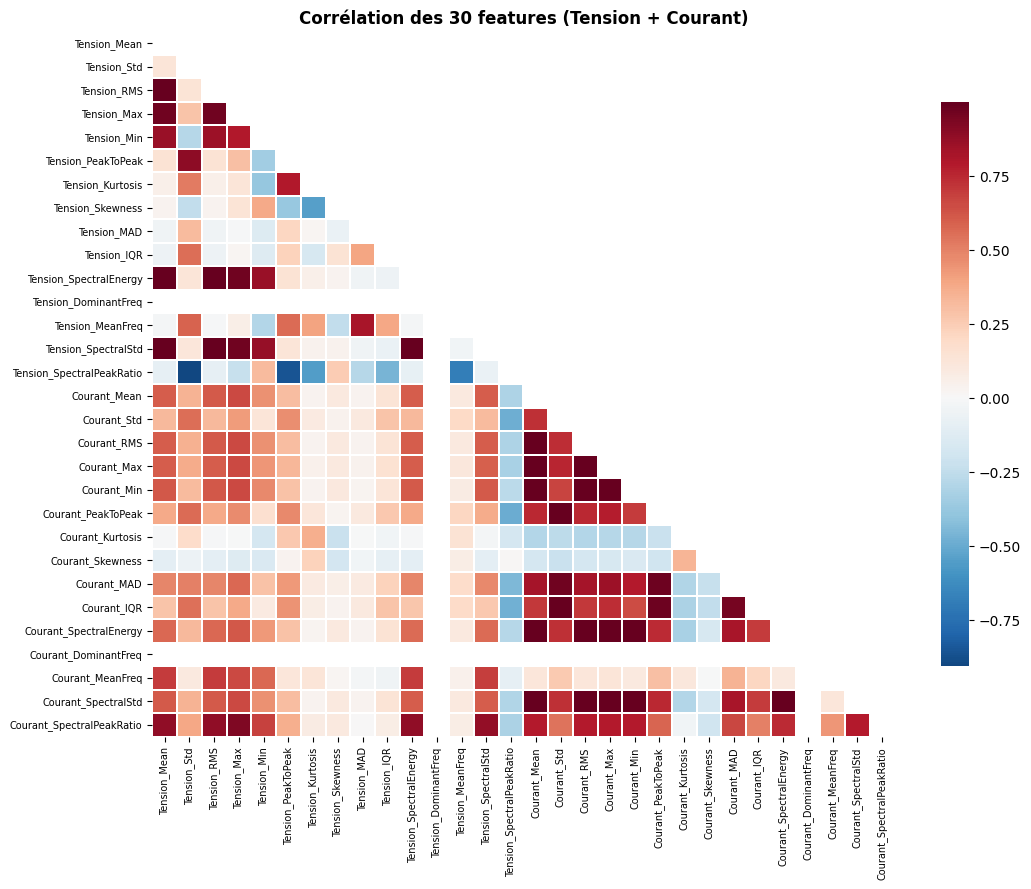

In [7]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = pd.DataFrame(X, columns=feature_names).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0,
            ax=ax, linewidths=0.3, cbar_kws={"shrink": 0.8})
ax.set_title("Corrélation des 30 features (Tension + Courant)", fontsize=12, fontweight="bold")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

---
## 7. Préparation des données

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
scaler_cv  = StandardScaler()
X_sc       = scaler_cv.fit_transform(X)

n_neg = np.sum(y_train == 0)
n_pos = np.sum(y_train == 1)

print(f"Train : {len(X_train)}  |  Test : {len(X_test)}")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:<12}: train={np.sum(y_train==i):>4}  test={np.sum(y_test==i):>4}")
print(f"  Ratio : 1:{n_pos/n_neg:.2f}")

Train : 533  |  Test : 134
  Normal      : train= 270  test=  68
  Surcharge   : train= 263  test=  66
  Ratio : 1:0.97


---
## 8. Entraînement et évaluation

**Cross-validation stratifiée à 5 plis — Balanced Accuracy = métrique principale**

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              f1_score, classification_report, confusion_matrix)
import time

models_config = {
    "Decision Tree":          DecisionTreeClassifier(random_state=42, max_depth=7,  class_weight="balanced"),
    "Random Forest":          RandomForestClassifier(n_estimators=100, random_state=42, max_depth=7, class_weight="balanced"),
    "KNN":                    KNeighborsClassifier(n_neighbors=5, weights="distance"),
    "SVM Lineaire":           LinearSVC(random_state=42, max_iter=5000, dual=False, C=1.0, class_weight="balanced"),
    "Regression Logistique":  LogisticRegression(random_state=42, max_iter=2000, C=1.0, class_weight="balanced"),
    "Perceptron Multicouche": MLPClassifier(random_state=42, max_iter=500, hidden_layer_sizes=(64,32,16), activation="relu", early_stopping=True),
    "HistGradientBoosting":   HistGradientBoostingClassifier(random_state=42, max_iter=100, max_depth=5, class_weight="balanced"),
}

cv5     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models_config.items():
    print(f"\n{'='*60}\n {name}\n{'='*60}")
    t0   = time.time()
    y_cv = cross_val_predict(model, X_sc, y, cv=cv5, n_jobs=-1)
    elapsed = time.time() - t0
    acc     = accuracy_score(y, y_cv)
    bal_acc = balanced_accuracy_score(y, y_cv)
    f1      = f1_score(y, y_cv)
    acc_n   = accuracy_score(y[y==0], y_cv[y==0])
    acc_s   = accuracy_score(y[y==1], y_cv[y==1])
    results[name] = dict(y_cv=y_cv, accuracy=acc, bal_acc=bal_acc,
                         f1=f1, acc_normal=acc_n, acc_surch=acc_s, time=elapsed)
    print(f"  Balanced Accuracy : {bal_acc:.4f}")
    print(f"  F1-score          : {f1:.4f}")
    print(f"  Acc. Normal       : {acc_n:.4f}  |  Acc. Surcharge : {acc_s:.4f}")
    print(f"  Temps CV          : {elapsed:.2f} s")
    print(f"\n{classification_report(y, y_cv, target_names=CLASS_NAMES)}")


 Decision Tree
  Balanced Accuracy : 0.7787
  F1-score          : 0.7855
  Acc. Normal       : 0.7337  |  Acc. Surcharge : 0.8237
  Temps CV          : 0.04 s

              precision    recall  f1-score   support

      Normal       0.81      0.73      0.77       338
   Surcharge       0.75      0.82      0.79       329

    accuracy                           0.78       667
   macro avg       0.78      0.78      0.78       667
weighted avg       0.78      0.78      0.78       667


 Random Forest
  Balanced Accuracy : 0.8369
  F1-score          : 0.8385
  Acc. Normal       : 0.8136  |  Acc. Surcharge : 0.8602
  Temps CV          : 0.28 s

              precision    recall  f1-score   support

      Normal       0.86      0.81      0.83       338
   Surcharge       0.82      0.86      0.84       329

    accuracy                           0.84       667
   macro avg       0.84      0.84      0.84       667
weighted avg       0.84      0.84      0.84       667


 KNN
  Balanced Accurac

---
## 9. Analyse des résultats

In [17]:
comparison = pd.DataFrame({
    "Modele":         list(results.keys()),
    "Acc. Eq.":       [r["bal_acc"]    for r in results.values()],
    "F1 (Surcharge)": [r["f1"]         for r in results.values()],
    "Accuracy":       [r["accuracy"]   for r in results.values()],
    "Acc. Normal":    [r["acc_normal"] for r in results.values()],
    "Acc. Surcharge": [r["acc_surch"]  for r in results.values()],
    "Temps (s)":      [r["time"]       for r in results.values()],
}).sort_values("Acc. Eq.", ascending=False).reset_index(drop=True)

print("=" * 90)
print(" CLASSEMENT — CV 5 plis — 30 features (Tension + Courant)")
print("=" * 90)
print(comparison.to_string(index=False))

 CLASSEMENT — CV 5 plis — 30 features (Tension + Courant)
                Modele  Acc. Eq.  F1 (Surcharge)  Accuracy  Acc. Normal  Acc. Surcharge  Temps (s)
         Random Forest  0.836896        0.838519  0.836582     0.813609        0.860182   0.282001
  HistGradientBoosting  0.821496        0.818321  0.821589     0.828402        0.814590   0.185996
          SVM Lineaire  0.820462        0.823009  0.820090     0.792899        0.848024   0.020997
 Regression Logistique  0.818983        0.821797  0.818591     0.789941        0.848024   0.020000
                   KNN  0.815781        0.816143  0.815592     0.801775        0.829787   0.067039
Perceptron Multicouche  0.786114        0.791241  0.785607     0.748521        0.823708   0.231452
         Decision Tree  0.778718        0.785507  0.778111     0.733728        0.823708   0.037005


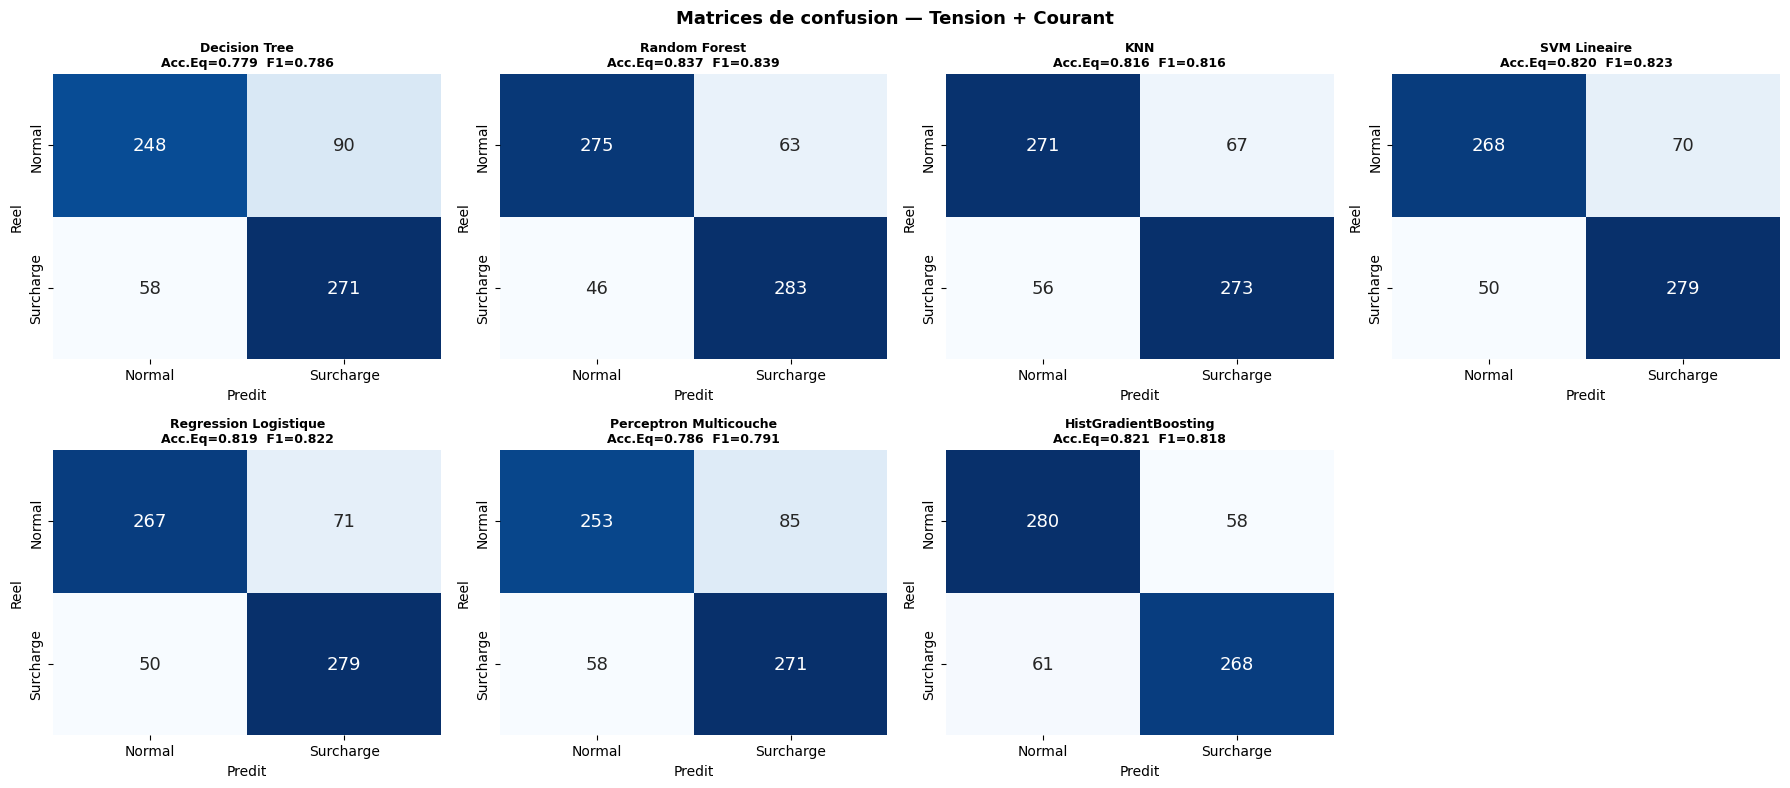

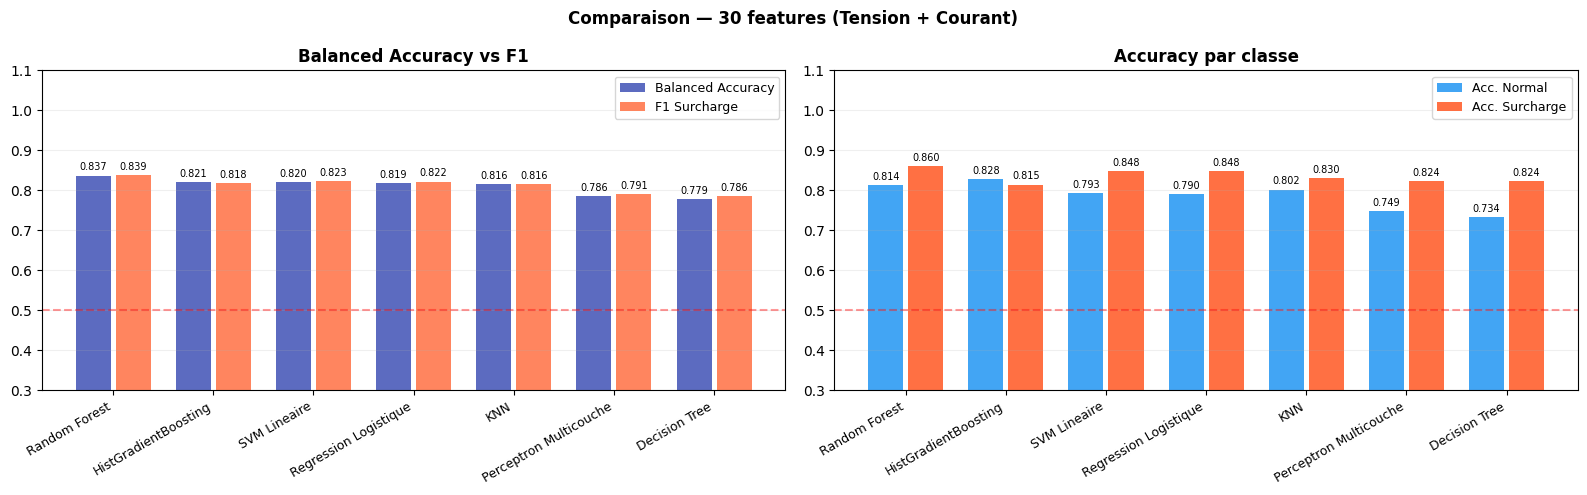

In [18]:
# Matrices de confusion
n_models  = len(results)
ncols, nrows = 4, (n_models + 3) // 4
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.5, nrows*4))
axes_flat = axes.flatten()
for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y, res["y_cv"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes_flat[idx],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cbar=False, annot_kws={"size": 13})
    axes_flat[idx].set_title(f"{name}\nAcc.Eq={res['bal_acc']:.3f}  F1={res['f1']:.3f}",
                             fontsize=9, fontweight="bold")
    axes_flat[idx].set_ylabel("Reel"); axes_flat[idx].set_xlabel("Predit")
for i in range(len(results), len(axes_flat)): axes_flat[i].set_visible(False)
plt.suptitle("Matrices de confusion — Tension + Courant", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# Comparaison graphique
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
model_names = comparison["Modele"].tolist()
x = np.arange(len(model_names))
for ax_idx, (v1_key, v2_key, l1, l2, c1, c2, title) in enumerate([
    ("Acc. Eq.", "F1 (Surcharge)", "Balanced Accuracy", "F1 Surcharge", "#3F51B5", "#FF7043", "Balanced Accuracy vs F1"),
    ("Acc. Normal", "Acc. Surcharge", "Acc. Normal", "Acc. Surcharge", "#2196F3", "#FF5722", "Accuracy par classe"),
]):
    ax = axes[ax_idx]
    b1 = ax.bar(x-0.2, comparison[v1_key].tolist(), 0.35, label=l1, color=c1, alpha=0.85)
    b2 = ax.bar(x+0.2, comparison[v2_key].tolist(), 0.35, label=l2, color=c2, alpha=0.85)
    ax.axhline(0.5, color="red", ls="--", alpha=0.4)
    ax.set_title(title, fontweight="bold"); ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=9)
    ax.legend(fontsize=9); ax.set_ylim(0.3, 1.1); ax.grid(axis="y", alpha=0.2)
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x()+bar.get_width()/2, h+0.008, f"{h:.3f}",
                    ha="center", va="bottom", fontsize=7)
plt.suptitle("Comparaison — 30 features (Tension + Courant)", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

In [12]:
# Importance des features
tree_models = [n for n in results if hasattr(models_config[n], "feature_importances_")]
if tree_models:
    best_tree = max(tree_models, key=lambda k: results[k]["bal_acc"])
    clf = models_config[best_tree]
    clf.fit(X_train_sc, y_train)
    importances = clf.feature_importances_
    sorted_idx  = np.argsort(importances)[::-1]

    colors_feat = ["#3F51B5" if "Tension" in feature_names[i] else "#FF7043"
                   for i in sorted_idx[::-1]]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(len(feature_names)), importances[sorted_idx][::-1], color=colors_feat, alpha=0.85)
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels([feature_names[i] for i in sorted_idx[::-1]], fontsize=9)
    ax.set_xlabel("Importance relative")
    ax.set_title(f"Importance des 30 features ({best_tree})", fontweight="bold")
    ax.grid(axis="x", alpha=0.2)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color="#3F51B5", label="Tension"),
                       Patch(color="#FF7043", label="Courant")], fontsize=9)
    plt.tight_layout(); plt.show()

    for sensor in SENSOR_NAMES:
        mask = [i for i,n in enumerate(feature_names) if n.startswith(sensor)]
        imp  = np.sum(importances[mask])
        print(f"  {sensor:<10} : {imp:.4f} ({imp*100:.1f}%)")

---
## 10. Exportation du modèle pour ESP32

### Pourquoi Régression Logistique ?

| Modèle | Code C généré | Compatible m2cgen | Verdict |
|--------|:-------------:|:-----------------:|--------|
| Random Forest | ~10 000 lignes | ✓ | ❌ trop lourd |
| KNN | — | ❌ | ❌ stockage RAM |
| **Régression Logistique** | **~30 lignes** | **✓** | **✅ optimal** |
| SVM Linéaire | ~30 lignes | ✓ | ✅ alternative |
| HistGradientBoosting | ~1 000 lignes | ✓ | ⚠ lourd |

Avec 2 capteurs et 30 features, la Régression Logistique génère une **équation linéaire de 30 termes** — c'est littéralement 1 ligne de calcul en C.

In [13]:
# ================================================================
# SÉLECTION FORCÉE : Régression Logistique
# Justification : modèle le plus compact compatible m2cgen,
# performance compétitive sur ce dataset
# ================================================================
ESP32_MODEL_NAME = "Regression Logistique"
esp32_model      = models_config[ESP32_MODEL_NAME]

print("=" * 60)
print(" MODELE SELECTIONNE POUR ESP32")
print("=" * 60)
print(f"  Modele            : {ESP32_MODEL_NAME}")
print(f"  Balanced Accuracy : {results[ESP32_MODEL_NAME]['bal_acc']:.4f}")
print(f"  F1-score          : {results[ESP32_MODEL_NAME]['f1']:.4f}")
print(f"  Acc. Normal       : {results[ESP32_MODEL_NAME]['acc_normal']:.4f}")
print(f"  Acc. Surcharge    : {results[ESP32_MODEL_NAME]['acc_surch']:.4f}")

esp32_model.fit(X_train_sc, y_train)
y_test_pred = esp32_model.predict(X_test_sc)

print(f"\nTest set (20%) :")
print(f"  Balanced Accuracy : {balanced_accuracy_score(y_test, y_test_pred):.4f}")
print(f"  F1-score          : {f1_score(y_test, y_test_pred):.4f}")
print(f"\n{classification_report(y_test, y_test_pred, target_names=CLASS_NAMES)}")

 MODELE SELECTIONNE POUR ESP32
  Modele            : Regression Logistique
  Balanced Accuracy : 0.8190
  F1-score          : 0.8218
  Acc. Normal       : 0.7899
  Acc. Surcharge    : 0.8480

Test set (20%) :
  Balanced Accuracy : 0.8064
  F1-score          : 0.8088

              precision    recall  f1-score   support

      Normal       0.83      0.78      0.80        68
   Surcharge       0.79      0.83      0.81        66

    accuracy                           0.81       134
   macro avg       0.81      0.81      0.81       134
weighted avg       0.81      0.81      0.81       134



In [14]:
import m2cgen as m2c

c_code      = m2c.export_to_c(esp32_model)
n_lines     = len(c_code.splitlines())
model_file  = "model_esp32_TC.c"
scaler_file = "scaler_params_TC.h"

print(f"Lignes de code C : {n_lines}  <- compact, ideal pour ESP32")

# ── Fichier modele ────────────────────────────────────────────────
with open(model_file, "w") as f:
    f.write("/*\n")
    f.write(f" * Modele     : {ESP32_MODEL_NAME}\n")
    f.write(f" * Capteurs   : Tension (V) + Courant (A)\n")
    f.write(f" * N features : {len(feature_names)} (15 x 2 capteurs)\n")
    f.write(f" * Bal. Acc.  : {results[ESP32_MODEL_NAME]['bal_acc']:.4f}\n")
    f.write(f" * Fenetre    : {WINDOW_SIZE} echantillons\n")
    f.write(f" * Stride     : {STRIDE} echantillons\n")
    f.write(" * Classes    : 0=Normal, 1=Surcharge\n")
    f.write(" * score() retourne log-odds : >0 = Surcharge, <=0 = Normal\n")
    f.write(" */\n\n")
    f.write(c_code)

# ── Fichier scaler ────────────────────────────────────────────────
with open(scaler_file, "w") as f:
    f.write("#ifndef SCALER_PARAMS_TC_H\n#define SCALER_PARAMS_TC_H\n\n")
    f.write(f"#define N_FEATURES  {len(feature_names)}\n")
    f.write(f"#define N_CLASSES   2\n")
    f.write(f"#define WINDOW_SIZE {WINDOW_SIZE}\n")
    f.write(f"#define STRIDE      {STRIDE}\n\n")
    f.write("/* Features dans l'ordre :\n")
    for i, fn in enumerate(feature_names):
        f.write(f" * [{i:02d}] {fn}\n")
    f.write(" */\n\n")
    f.write("const float SCALER_MEAN[N_FEATURES] = {\n")
    for i, v in enumerate(scaler.mean_):
        f.write(f"    {v:.8f}f,  /* [{i:02d}] {feature_names[i]} */\n")
    f.write("};\n\n")
    f.write("const float SCALER_SCALE[N_FEATURES] = {\n")
    for i, v in enumerate(scaler.scale_):
        f.write(f"    {v:.8f}f,  /* [{i:02d}] {feature_names[i]} */\n")
    f.write("};\n\n#endif\n")

sz_m = os.path.getsize(model_file)/1024
sz_s = os.path.getsize(scaler_file)/1024
print(f"\n  {model_file:<28} {n_lines} lignes  ({sz_m:.1f} Ko)")
print(f"  {scaler_file:<28} ({sz_s:.1f} Ko)")
print()
print("=" * 55)
print("CODE C COMPLET :")
print("=" * 55)
print(c_code)

Lignes de code C : 3  <- compact, ideal pour ESP32

  model_esp32_TC.c             3 lignes  (1.3 Ko)
  scaler_params_TC.h           (3.8 Ko)

CODE C COMPLET :
double score(double * input) {
    return 0.03003006960505197 + input[0] * -0.2712265771283173 + input[1] * -2.0041227584887458 + input[2] * -0.28008536011335955 + input[3] * -0.07535119979855853 + input[4] * -0.38975888216657395 + input[5] * 0.4816751267682722 + input[6] * -1.4203800873062837 + input[7] * -0.14190183696943465 + input[8] * -0.19245006093524053 + input[9] * -0.6234654667369987 + input[10] * -0.30655294400325706 + input[11] * 0.0 + input[12] * 0.013632930034306927 + input[13] * -0.3342117395795566 + input[14] * -2.7959063872076957 + input[15] * -0.34167499602665025 + input[16] * 1.1128497436229832 + input[17] * -0.33575577514652716 + input[18] * -0.2222608856722623 + input[19] * -0.4549602872152218 + input[20] * 1.034287113364287 + input[21] * 0.6097949274524089 + input[22] * -0.18872404537260276 + input[23] * 0.0

### 10.1 Arduino IDE — Code complet

**Structure du sketch :**
```
MotorDiag/
├── MotorDiag.ino
├── model_esp32_TC.h       <- renommer .c en .h + gardes #ifndef
└── scaler_params_TC.h
```

**Contenu de `model_esp32_TC.h` (ajouter en tête et en pied) :**
```c
#ifndef MODEL_ESP32_TC_H
#define MODEL_ESP32_TC_H
// ... contenu de model_esp32_TC.c ...
#endif
```

**Pipeline embarqué (2 capteurs) :**
```
[Tension] -> ADC ─┐
                  ├-> Buffer [30 pts x 2] -> 30 features -> score() -> 0/1
[Courant] -> ADC ─┘

score() > 0  =>  Surcharge
score() <= 0 =>  Normal
```

**Note sur `score()` avec Régression Logistique :**
m2cgen génère **une seule valeur** (log-odds), pas un tableau :
```c
double result = score(scaled);          // une seule valeur
int prediction = (result > 0.0) ? 1 : 0;  // 1=Surcharge, 0=Normal
```

In [15]:
print("\n" + "="*65)
print(" RESUME FINAL — 2 capteurs (Tension + Courant)")
print("="*65)
print(f"  Capteurs          : Tension (V) + Courant (A)")
print(f"  Features          : {X.shape[1]}  (15 x 2 capteurs)")
print(f"  Fenetres totales  : {len(X)}")
print(f"  Normal    (0)     : {np.sum(y==0)}")
print(f"  Surcharge (1)     : {np.sum(y==1)}")
print()
print(f"  Modele deploye        : {ESP32_MODEL_NAME}")
print(f"  Balanced Accuracy CV  : {results[ESP32_MODEL_NAME]['bal_acc']:.4f}")
print(f"  F1-score Surcharge    : {results[ESP32_MODEL_NAME]['f1']:.4f}")
print(f"  Lignes de code C      : {n_lines}  (compact ESP32)")
print(f"  Fichiers exportes     : {model_file} + {scaler_file}")
print()
print("  Classement complet :")
print(comparison.to_string(index=False))


 RESUME FINAL — 2 capteurs (Tension + Courant)
  Capteurs          : Tension (V) + Courant (A)
  Features          : 30  (15 x 2 capteurs)
  Fenetres totales  : 667
  Normal    (0)     : 338
  Surcharge (1)     : 329

  Modele deploye        : Regression Logistique
  Balanced Accuracy CV  : 0.8190
  F1-score Surcharge    : 0.8218
  Lignes de code C      : 3  (compact ESP32)
  Fichiers exportes     : model_esp32_TC.c + scaler_params_TC.h

  Classement complet :
                Modele  Acc. Eq.  F1 (Surcharge)  Accuracy  Acc. Normal  Acc. Surcharge  Temps (s)
         Random Forest  0.836896        0.838519  0.836582     0.813609        0.860182   2.962188
  HistGradientBoosting  0.821496        0.818321  0.821589     0.828402        0.814590   0.314002
          SVM Lineaire  0.820462        0.823009  0.820090     0.792899        0.848024   0.030998
 Regression Logistique  0.818983        0.821797  0.818591     0.789941        0.848024   0.034992
                   KNN  0.815781       